In [13]:
import time

import numpy as np
import math

In [14]:
grid5 = np.array([
    [0, 0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 0, 0, 0, 0],        
    [1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.int8)

In [15]:
grid = grid5
n, m = grid.shape
print(f"Kích thước lưới: {n} x {m}")

# B1: tính ma trận khoảng cách d như bạn đã làm
start = time.time()

# khởi tạo một ma trận NumPy có tên là d. Ma trận này có kích thước n x n
# (tương đương với kích thước của lưới grid).
# Nó được điền đầy bằng một giá trị rất lớn (1e10), đại diện cho 'vô cùng'.
# Điều này có nghĩa là ban đầu, tất cả các ô trên lưới đều được coi là không thể
# tiếp cận được từ điểm xuất phát. dtype=np.float64 chỉ định rằng các phần tử của
# ma trận sẽ là số thực có độ chính xác cao, cần thiết cho các phép tính khoảng cách
# (ví dụ như math.sqrt(2)).

# d[i][j] lưu trữ độ dài đường đi ngắn nhất từ điểm xuất phát (0,0) đến ô có tọa độ (i,j) trên lưới
d = np.full((n, m), fill_value=1e10, dtype=np.float64)
d[0][0] = 0

for i in range(1, n):
    if not grid[i][0]:
        d[i][0] = min(d[i][0], d[i-1][0] + 1)

for j in range(1, m):
    if not grid[0][j]:
        d[0][j] = min(d[0][j], d[0][j-1] + 1)

for i in range(1, n):
    for j in range(1, m):
        if not grid[i][j]:
            d[i][j] = min(
                d[i][j],
                d[i-1][j] + 1,          # đi xuống
                d[i][j-1] + 1,          # đi sang phải
                d[i-1][j-1] + math.sqrt(2)  # đi chéo
            )

print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][m-1])

# B2: truy vết đường đi từ (n-1, m-1) về (0,0)
path = []
i, j = n-1, m-1

if d[i, j] > 1e9:
    print("Không có đường đi hợp lệ tới đích")
else:
    while not (i == 0 and j == 0):
        path.append((i, j))
        found = False
        # Thử lần lượt: chéo, lên, trái (ưu tiên chéo cho đẹp)
        for di, dj, cost in [(-1, -1, math.sqrt(2)), (-1, 0, 1), (0, -1, 1)]:
            pi, pj = i + di, j + dj
            if pi < 0 or pj < 0:
                continue
            # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
            if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                i, j = pi, pj
                found = True
                break
        if not found:
            raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

    path.append((0, 0))
    path.reverse()

    print("Đường đi ngắn nhất (theo thứ tự):")
    for cell in path:
        print(cell)

end = time.time()
elapsed = end - start
print(f"Thời gian chạy: {elapsed:.6f} giây")

Kích thước lưới: 9 x 9
Độ dài đường đi ngắn nhất tới đích: 11.313708498984763
Đường đi ngắn nhất (theo thứ tự):
(0, 0)
(1, 1)
(2, 2)
(3, 3)
(4, 4)
(5, 5)
(6, 6)
(7, 7)
(8, 8)
Thời gian chạy: 0.000878 giây



Visualizing Q-Learning path...


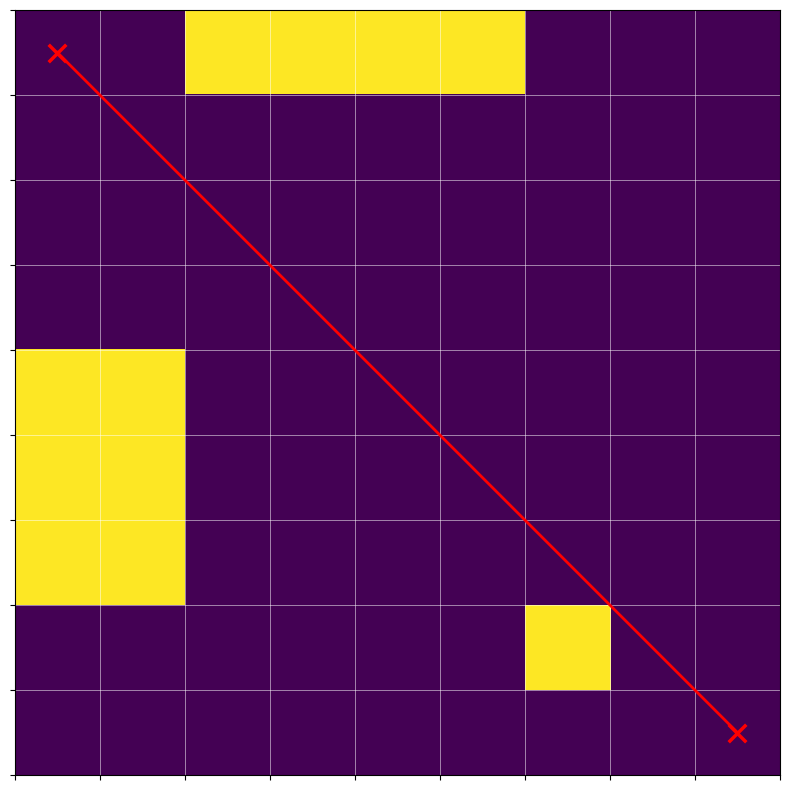

In [16]:
import matplotlib.pyplot as plt
import numpy as np

if path:
    print("\nVisualizing Q-Learning path...")
    fig, ax = plt.subplots(figsize=(8, 8))

    # ===== 1. Vẽ nền: lưới sau bao lồi (expanded_grid) =====
    im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

    # ===== 2. Tô màu riêng các ô được bổ sung thêm (expanded_grid = 1, pre_grid = 0) =====
    # Tạo mask cho các ô "mới"
    added_mask = ((grid == 1) & (grid == 0)).astype(int)

    # Biến 0 thành trong suốt, chỉ giữ lại ô = 1 để tô màu
    added_mask = np.ma.masked_where(added_mask == 0, added_mask)

    # Vẽ đè lớp các ô bổ sung: chọn một colormap dễ nhìn, ví dụ 'autumn' hoặc 'Reds'
    ax.imshow(
        added_mask,
        origin="upper",
        interpolation="nearest",
        cmap="autumn",   # ô bổ sung sẽ có màu khác hẳn (vàng/đỏ)
        alpha=0.7,       # hơi trong suốt để vẫn thấy nền phía dưới
        zorder=2
    )

    # ===== 3. Vẽ đường đi =====
    xs = [p[1] for p in path]  # Swap x,y for plotting
    ys = [p[0] for p in path]
    ax.plot(xs, ys, linewidth=2, color="red", zorder=3)
    ax.scatter(
        [path[0][1], path[-1][1]],
        [path[0][0], path[-1][0]],
        marker="x", s=160, linewidths=2.5, color="red", zorder=4
    )

    # ===== 4. Lưới ô như cũ =====
    n, m = grid.shape
    ax.set_xlim(-0.5, m - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(-0.5, m, 1), minor=False)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

    plt.tight_layout()
    plt.show()

else:
    print("\nCould not extract a valid path from Q-table.")